In [1]:
import sys
sys.path.append("/vast/home/apasubramanyam/Entropy")

In [3]:
import os
import glob
import binary_entropy as entropy
import numpy as np
import random
import copy
import pickle
import spglib
import pandas as pd
import ase.io.lammpsdata
from ase.io import read, write
import matplotlib.pyplot as plt

from ase.optimize.bfgslinesearch import BFGSLineSearch
from ase.calculators.lammpslib import LAMMPSlib

import jax
import jax.numpy as jaxnp
from jax import grad, jit, vmap
from functools import partial
# from pybispectrum import calc_bispectrum_names

In [4]:
class CNModel:

    def __init__(self, n_elements, n_descriptors_tot, energy_mode=True, populations=None, mask=None, cross_=None, renorm_=None, mean_=None, count_=0, epsilon_=1e-6):
        #required by MLIAPPY
        self.n_params=1
        self.n_elements=n_elements
        self.epsilon=epsilon_
        self.n_descriptors = n_descriptors_tot
        
        self.n_elements = n_elements
        self.energy_mode=energy_mode
        
        self.active=True
        self.count=count_
        if mask is None:
            mask = list(range(n_descriptors_tot))
        self.mask = mask
        self.n_descriptors_keep = len(self.mask)
        
        if self.count==0:
            self.active=False
            self.renorm=None
            self.mean=None
            self.cross=None
            return
        else:
            self.renorm=renorm_
            self.mean=mean_
            self.cross=cross_
            
        if self.renorm is None:
            self.renorm=np.identity(self.n_descriptors_keep)
        if self.mean is None:
            self.renorm=np.zeros(self.n_descriptors_keep)
            
        self.populations=populations
        self.reg=self.epsilon*np.identity(self.n_descriptors_keep)
        
        self.cn_grad=grad(self.cn)
        
        self.K = 1
               
        
    @partial(jit, static_argnums=(0,))
    def cn(self,descriptors):
        d=descriptors-self.mean
        
        if self.energy_mode:
            d=jaxnp.mean(descriptors,axis=0)
            d=d.reshape((1,-1))
            
        if self.active:
            effective_count=self.count+d.shape[0]
            information=(self.cross + d.T@d)/effective_count 
            projected_information=jaxnp.divide(information,renorm) + self.reg
            #print (projected_information.shape)
            #return -jaxnp.log( jaxnp.linalg.det(projected_information) + 1e-12)
            (sign, logabsdet) = jaxnp.linalg.slogdet(projected_information)
            return -logabsdet
        else:
            return 0
    
        
    
    def __call__(self, elems, bispectrum, beta, energy):
        self.last_bispectrum=bispectrum.copy()
        b = bispectrum[:, self.mask]
        
        if self.active:
            energy[:] = 0
            energy[0] = self.K*self.cn(b)         
            b = self.K*self.cn_grad(b)
            beta[:, :] = 0
            beta[:, self.mask] = b
            
            if not jaxnp.all(jaxnp.isfinite(b)):
                print("GRAD ERROR!")
                #print(b)

          
        else:
            energy[:] = 0
            beta[:, :] = 0        
 
            
        #cleanup the jax cache. Seems to be required, otherwise can grow without bound and crash the code
        if self.cn._cache_size() > 30:
            self.cn._clear_cache()
            import gc
            import sys
            for module_name, module in sys.modules.items():
                if module_name.startswith("jax"):
                    if module_name not in ["jax.interpreters.partial_eval"]:
                        for obj_name in dir(module):
                            obj = getattr(module, obj_name)
                            if hasattr(obj, "cache_clear"):
                                try:
                                    obj.cache_clear()
                                except:
                                    pass

            gc.collect()
            
class CNManager:
    def __init__(self, n_descriptors, epsilon=0, mean=None, renorm=None, energy_mode=True):
        self.epsilon=epsilon
        self.count=0
        self.n_descriptors = n_descriptors
        self.sum=np.zeros((self.n_descriptors,))
        self.cross=np.zeros((self.n_descriptors, self.n_descriptors))
        self.reg=epsilon*np.identity(self.n_descriptors)
        self.data=[]
        self.s=None
        self.mean=mean
        self.renorm=renorm
        self.energy_mode=energy_mode
        
        if self.mean is None:
            self.mean=np.zeros((self.n_descriptors,))
            
        if self.renorm is None:
            self.renorm=np.ones((self.n_descriptors, self.n_descriptors))
            
            
    def print_status(self):
        self.evaluate()
        print("STATUS  -- COUNT ",self.count, " COND: ", np.linalg.cond(self.projected_information), "DET: ", -np.log( np.linalg.det(self.projected_information)) , flush=True)


    def update(self, dd, key=None):    
        self.data.append(dd)
        dt=dd-self.mean
        
        if self.energy_mode:
            dt=np.mean(dt,axis=0)
            dt=dt.reshape((1,-1))
        
        self.sum+=np.sum(dt,axis=0)
        self.cross+=dt.T@dt
        self.count+=dt.shape[0]
               
        #this is the covariance matrix of the descriptors
        information= self.cross/self.count 
        projected_information=np.divide(information,self.renorm)
        projected_information += self.reg
        
        try:
            u,s,vh=np.linalg.svd(projected_information)
            self.s=s
            #print(s)
            #print("CURRENT DB: ",self.count, keep, " PROJECTED: ", np.linalg.cond(projected_information), -np.log( np.linalg.det(projected_information)), "RAW: ", np.linalg.cond(information), -np.log( np.linalg.det(information)) , flush=True)
            #print(len(self.data))
        except:
            pass
    
        
    def evaluate(self,dd=None,key=None):
        effective_count=self.count
        if not dd is None:
            dt=dd-self.mean
            if self.energy_mode:
                dt=np.mean(dt,axis=0)
                dt=dt.reshape((1,-1))
            
            cross=self.cross.copy()
            cross+=dt.T@dt
            effective_count+=dt.shape[0]
            information=(cross)/effective_count 
        else:
            information= self.cross/effective_count 
            
        projected_information=np.divide(information,self.renorm) + self.reg
        self.projected_information=projected_information
        #return np.linalg.cond(projected_information), -np.log(np.linalg.det(projected_information))
        #print (projected_information.shape)
        (sign, logabsdet) = jaxnp.linalg.slogdet(projected_information)
        return jaxnp.linalg.cond(projected_information), -logabsdet

In [5]:
from ase.data import covalent_radii, atomic_numbers

covalent = {"H": covalent_radii[atomic_numbers["H"]], 
            "Be": covalent_radii[atomic_numbers["Be"]], 
            "C": covalent_radii[atomic_numbers["C"]], 
            "Al": covalent_radii[atomic_numbers["Al"]], 
            "W": covalent_radii[atomic_numbers["W"]], 
            "Re": covalent_radii[atomic_numbers["Re"]], 
            "Os": covalent_radii[atomic_numbers["Os"]], 
            "Sb": covalent_radii[atomic_numbers["Sb"]], 
            "Te": covalent_radii[atomic_numbers["Te"]], 
            "Cs": covalent_radii[atomic_numbers["Cs"]], 
            "Pu": covalent_radii[atomic_numbers["Pu"]], 
            "U": covalent_radii[atomic_numbers["U"]], 
            "O": covalent_radii[atomic_numbers["O"]]}


#from https://www.knowledgedoor.com/2/elements_handbook/nearest_neighbor_distance.html => 
# --> p. 21 in Charles Kittel. Introduction to Solid State Physics, 8th edition. Hoboken, NJ: John Wiley & Sons, Inc, 2005.
NN_dists = {"H":0.75, 
            "Be": 2.22, 
            "C": 1.54, 
            "Al": 2.86, 
            "W": 2.74, 
            "Re": 2.74, 
            "Os": 2.68, 
            "Pu": 3.1, 
            "U": 2.75, 
            "O": 1.2, 
            "Sb": 2.91, 
            "Te": 2.86, 
            "Cs": 5.24}

#https://www.wiredchemist.com/chemistry/data/metallic-radii
metallic = {"Be": 1.12, 
           "Al": 1.43, 
           "W": 1.41, 
           "Re": 1.35, 
           "Os": 1.35, 
           "Sb": 1.61, 
           "Cs": 2.72, 
           "U": 1.56}

In [6]:
def get_AB_distances(atoms):
    
    dists=atoms.get_all_distances(mic=True)
    dists+=1000*np.identity(n_atoms)
    cell_lengths = atoms.cell.lengths()
    
    symbols = atoms.get_chemical_symbols()
    indices_Be = [ind for ind in range(len(symbols)) if symbols[ind]=="Sb"]
    indices_W  = [ind for ind in range(len(symbols)) if symbols[ind]=="Pu"]
    
    if len(atoms) == 2:
        dists_WBe = [dists[i][j] for i in indices_Be for j in indices_W]
        dists_W = dists_Be = np.min(cell_lengths)
        
    else:
        if len(indices_Be)==1:
            dists_Be = np.min(cell_lengths)
            dists_W = [dists[i][j] for i in indices_W for j in indices_W]
            dists_WBe = [dists[i][j] for i in indices_Be for j in indices_W]
        elif len(indices_W)==1:
            dists_W = np.min(cell_lengths)
            dists_Be = [dists[i][j] for i in indices_Be for j in indices_Be]
            dists_WBe = [dists[i][j] for i in indices_Be for j in indices_W]
        else:
            dists_Be = [dists[i][j] for i in indices_Be for j in indices_Be]
            dists_W = [dists[i][j] for i in indices_W for j in indices_W]
            dists_WBe = [dists[i][j] for i in indices_Be for j in indices_W]
        
    return dists_Be, dists_W, dists_WBe

In [7]:
def write_mliap_descriptor(rcutfac=4.67637, twojmax=6, radelems="0.5 0.5"): #4.812302818
    with open("WBe.mliap.descriptor", "w") as f:
        f.write("# DATE: 2014-09-05 UNITS: metal CONTRIBUTOR: Aidan Thompson athomps@sandia.gov CITATION: Thompson, Swiler, Trott, Foiles and Tucker, arxiv.org, 1409.3880 (2014)\n")
        f.write("# LAMMPS SNAP parameters for Ta_Cand06A\n")
        f.write("# required\n")
        f.write("rcutfac {} \n".format(rcutfac))
        f.write("twojmax {} \n".format(twojmax))
        f.write("# elements\n")
        f.write("nelems 2\n")
        f.write("elems Sb Pu \n")
        #f.write("type Be W \n")
        f.write("radelems {} \n".format(radelems))
        f.write("welems 1 1\n")
        f.write("chemflag 1 \n")
        f.write("# optional\n")
        f.write("rfac0 0.99363\n")
        f.write("rmin0 0\n")
        f.write("bzeroflag 0\n")

In [8]:
rcut_W = NN_dists["Pu"]*2 #4.67637
rcut_Be = NN_dists["Sb"]*2

radelems_W  = 0.5
radelems_Be = np.round((rcut_Be*radelems_W)/rcut_W, 4)

radelems = str(radelems_Be) + " " + str(radelems_W)

write_mliap_descriptor(rcutfac=rcut_W, twojmax=4, radelems=radelems)

In [9]:
radelems, rcut_W, rcut_Be

('0.4694 0.5', 6.2, 5.82)

In [10]:
#total number of available descriptors
# bispec_names = calc_bispectrum_names(twojmax=4)
# n_bispec = len(bispec_names)
n_bispec = 14
n_descriptors_tot=((2**3)*n_bispec)
base_mask=list(range(n_descriptors_tot))

In [11]:
#work on n_keep descriptors at the time
n_keep=n_descriptors_tot
print (n_keep)

epsilon=1e-4

#initial strenght of the entropy term
K_init=3.

#use energy mode or force mode
energy_mode=True

#enforce entropy decrease before accepting configuration
strict_entropy_decrease=True

112


In [12]:
generate_zero_t =\
"""
pair_style soft 5.0
pair_coeff 1 1 10 %f
pair_coeff 1 2 8 %f
pair_coeff 2 2 5 %f
""" 

generate_min_t =\
"""
pair_style hybrid/overlay soft 5 mliap model mliappy LATER descriptor sna WBe.mliap.descriptor
pair_coeff 1 1 soft 10 %f
pair_coeff 1 2 soft 10 %f
pair_coeff 2 2 soft 10 %f
pair_coeff * * mliap Sb Pu
"""

In [13]:
core_radius_W  = NN_dists["Pu"]
Volume_W = ((np.sqrt(2)*core_radius_W)**3)/4.

core_radii_Be  = NN_dists["Sb"]*np.arange(0.7, 1.8, 0.15)

NN_dists_WBe   = NN_dists["Pu"]/2. + NN_dists["Sb"]/2.
core_radii_WBe = NN_dists_WBe*np.arange(0.7, 1.8, 0.15)

radii_to_sample = [[c_Be, c_WBe] for c_Be in core_radii_Be for c_WBe in core_radii_WBe]

In [14]:
print (NN_dists["Pu"], NN_dists["Sb"])

3.1 2.91


In [15]:
print (core_radii_Be)
print (core_radius_W)
print (core_radii_WBe)

[2.037  2.4735 2.91   3.3465 3.783  4.2195 4.656  5.0925]
3.1
[2.1035  2.55425 3.005   3.45575 3.9065  4.35725 4.808   5.25875]


In [16]:
print ("Sb:", set(np.array(radii_to_sample)[:,0]), 
       "\nPuSb:", set(np.array(radii_to_sample)[:,1]))

Sb: {2.91, 3.3465, 2.037, 2.4735, 3.7830000000000004, 4.219500000000001, 4.656000000000001, 5.092500000000001} 
PuSb: {2.1035, 3.005, 2.5542499999999997, 3.4557499999999997, 3.9065, 4.3572500000000005, 4.808, 5.258750000000001}


In [17]:
len(radii_to_sample)

64

In [18]:
n_elems=2
atom_types={"Sb":1, "Pu":2}

N_atoms = range(2, 26)

shapes=[ [4, 1, 1], [1, 1, 1], [3, 3, 1] ]

In [19]:
manager_random=CNManager(n_descriptors_tot)

model=CNModel(n_elems, n_descriptors_tot, 
              energy_mode=energy_mode, populations=None, 
              mask=None, cross_=None, 
              renorm_=None, mean_=None, 
              count_=0, epsilon_=epsilon)

In [ ]:
target_V = []
target_D = []
i=0
while i<100:
    n_atoms    = random.choice(N_atoms)
    shape      = random.choice(shapes)
    allowed_Be = range(1, n_atoms)
    n_Be       = random.choice(allowed_Be)
    Be_conc    = float(n_Be/n_atoms)
    
    rad = random.choice(radii_to_sample)
    core_radius_Be  = rad[0]
    core_radius_WBe = rad[1]
    
    min_distance_W   = core_radius_W*0.9
    min_distance_Be  = core_radius_Be*0.9
    min_distance_WBe = core_radius_WBe*0.9
    
    Volume_Be      = ((np.sqrt(2)*core_radius_Be)**3)/4.
    Volume_WBe     = (n_Be*Volume_Be + (n_atoms-n_Be)*Volume_W)/n_atoms
    target_volume  = Volume_WBe*random.uniform(0.9, 1.9)
    target_V.append(target_volume)
    
    print (n_atoms, n_Be, shape, target_volume)
    print (min_distance_W, min_distance_Be, min_distance_WBe)

    symbols = int(n_Be)*["Sb"] + int(n_atoms-n_Be)*["Pu"]
    
    generate_zero = generate_zero_t % (min_distance_Be, min_distance_WBe, min_distance_W)
    calculator_relax = LAMMPSlib(lmpcmds=generate_zero.split("\n"),
                                 log_file=None,
                                 keep_alive=True,
                                 atom_types=atom_types)
    
    generate_min = generate_min_t % (core_radius_Be, core_radius_WBe, core_radius_W)
    calculator_min = entropy.EntropyCalculator(lmpcmds=generate_min.split("\n"),
                                               log_file=None,
                                               model=model,
                                               keep_alive=True,
                                               atom_types=atom_types)
    

    try:
        print ("Generating atoms")
        ratio_of_covalent_radii = 0.5
        atoms = entropy.generate_random_cell(symbols, target_volume=target_volume, shape=shape, ratio_of_covalent_radii=ratio_of_covalent_radii)

        dists_Be, dists_W, dists_WBe = get_AB_distances(atoms)
        print (np.min(dists_W), np.min(dists_Be), np.min(dists_WBe))
        
        #relax with the core repulsion alone
        print ("Relaxing with core repulsion")
        atoms.calc=calculator_relax
        opt = BFGSLineSearch(atoms, force_consistent=True,logfile="log_relax")
        opt.run(fmax=0.05, steps=50)
        
        #No optimizing with the entropy model
        atoms.calc=calculator_min
        d=entropy.compute_descriptors(atoms)
                
        dists_Be, dists_W, dists_WBe = get_AB_distances(atoms)
        print (np.min(dists_W), np.min(dists_Be), np.min(dists_WBe))

        if (np.min(dists_Be) > min_distance_Be) and (np.min(dists_W) > min_distance_W) and (np.min(dists_WBe) > min_distance_WBe):
            dists_cond = True
        else:
            dists_cond = False

        if dists_cond:
            print ("Compute descriptors and update")
            print (np.min(dists_W), np.min(dists_Be), np.min(dists_WBe))
            target_D.append([np.min(dists_W), np.min(dists_Be), np.min(dists_WBe)])
            manager_random.update(d)
            ase.io.lammpsdata.write_lammps_data("renorm_configs/renorm_config_"+str(i)+".dat", atoms)
            i+=1
    except:
        pass
    
    print ("\n")

25 22 [1, 1, 1] 47.33069920430976
2.79 3.797550000000001 3.51585
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}


9 7 [4, 1, 1] 60.954134602881346
2.79 3.4047000000000005 3.110175
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}
2.803013556541228 1.640134646406148 2.4362827800989746
Relaxing with core repulsion


15 1 [1, 1, 1] 34.4987395335846
2.79 3.4047000000000005 4.3272
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}
1.8859281813056794 5.942601785323274 2.4070484912005585
Relaxing with core repulsion


3 1 [4, 1, 1] 21.370821994422936
2.79 3.01185 1.8931499999999999
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}
4.132549687909021 2.0418409150668895 2.023037413721873
Relaxing with core repulsion


18 9 [3, 3, 1] 19.284234512272633
2.79 1.8333 4.732875000000001
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}
1.7214

In [19]:
target_V = []
target_D = []
i=0
while i<100:
    n_atoms    = random.choice(N_atoms)
    shape      = random.choice(shapes)
    allowed_Be = range(1, n_atoms)
    n_Be       = random.choice(allowed_Be)
    Be_conc    = float(n_Be/n_atoms)
    
    rad = random.choice(radii_to_sample)
    core_radius_Be  = rad[0]
    core_radius_WBe = rad[1]
    
    min_distance_W   = core_radius_W*0.9
    min_distance_Be  = core_radius_Be*0.9
    min_distance_WBe = core_radius_WBe*0.9
    
    Volume_Be      = ((np.sqrt(2)*core_radius_Be)**3)/4.
    Volume_WBe     = (n_Be*Volume_Be + (n_atoms-n_Be)*Volume_W)/n_atoms
    target_volume  = Volume_WBe*random.uniform(0.9, 1.9)
    target_V.append(target_volume)
    
    print (n_atoms, n_Be, shape, target_volume)
    print (min_distance_W, min_distance_Be, min_distance_WBe)

    symbols = int(n_Be)*["Sb"] + int(n_atoms-n_Be)*["Pu"]
    
    generate_zero = generate_zero_t % (min_distance_Be, min_distance_WBe, min_distance_W)
    calculator_relax = LAMMPSlib(lmpcmds=generate_zero.split("\n"),
                                 log_file=None,
                                 keep_alive=True,
                                 atom_types=atom_types)
    
    generate_min = generate_min_t % (core_radius_Be, core_radius_WBe, core_radius_W)
    calculator_min = entropy.EntropyCalculator(lmpcmds=generate_min.split("\n"),
                                               log_file=None,
                                               model=model,
                                               keep_alive=True,
                                               atom_types=atom_types)
    

    try:
        print ("Generating atoms")
        ratio_of_covalent_radii = 0.5
        atoms = entropy.generate_random_cell(symbols, target_volume=target_volume, shape=shape, ratio_of_covalent_radii=ratio_of_covalent_radii)

        dists_Be, dists_W, dists_WBe = get_AB_distances(atoms)
        print (np.min(dists_W), np.min(dists_Be), np.min(dists_WBe))
        
        #relax with the core repulsion alone
        print ("Relaxing with core repulsion")
        atoms.calc=calculator_relax
        opt = BFGSLineSearch(atoms, force_consistent=True,logfile="log_relax")
        opt.run(fmax=0.05, steps=50)
        
        #No optimizing with the entropy model
        atoms.calc=calculator_min
        d=entropy.compute_descriptors(atoms)
                
        dists_Be, dists_W, dists_WBe = get_AB_distances(atoms)
        print (np.min(dists_W), np.min(dists_Be), np.min(dists_WBe))

        if (np.min(dists_Be) > min_distance_Be) and (np.min(dists_W) > min_distance_W) and (np.min(dists_WBe) > min_distance_WBe):
            dists_cond = True
        else:
            dists_cond = False

        if dists_cond:
            print ("Compute descriptors and update")
            print (np.min(dists_W), np.min(dists_Be), np.min(dists_WBe))
            target_D.append([np.min(dists_W), np.min(dists_Be), np.min(dists_WBe)])
            manager_random.update(d)
            ase.io.lammpsdata.write_lammps_data("renorm_configs/renorm_config_"+str(i)+".dat", atoms)
            i+=1
    except:
        pass
    
    print ("\n")

13 5 [3, 3, 1] 22.480026731340946
2.79 3.01185 4.732875000000001
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}
1.8433100545800274 1.471728092060544 1.6397646988098595
Relaxing with core repulsion
2.0977972780778575 2.495053017669758 3.240556194075671


13 11 [1, 1, 1] 99.60704527671415
2.79 4.583250000000001 4.3272
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}


13 10 [3, 3, 1] 18.759355015154398
2.79 2.619 3.9215250000000004
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}
2.7990335359944574 1.3384301826278613 1.6068082158989965
Relaxing with core repulsion
2.1108491123987387 2.435548571800644 3.308597542963881


23 20 [3, 3, 1] 129.48410716704495
2.79 4.583250000000001 2.7045
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}


20 14 [1, 1, 1] 53.08534979128871
2.79 3.797550000000001 3.110175
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51)

/vast/home/apasubramanyam/.conda/envs/mliap/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


1.9466431245356686 1.9962168209490425 3.303070037418227


18 9 [3, 3, 1] 92.43317133562098
2.79 4.583250000000001 2.7045
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}


18 5 [1, 1, 1] 25.619794323271698
2.79 3.01185 2.7045
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}
1.7346878062540052 1.8620293968166697 1.4964739362703738
Relaxing with core repulsion
2.7845966353497342 3.0110979810349097 2.702869722628311


6 2 [3, 3, 1] 35.565636571524294
2.79 3.4047000000000005 4.3272
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}
3.0569977316297763 3.298546529927251 1.7415478420190207
Relaxing with core repulsion
2.6336374410246126 3.3455632653454708 4.166127634588605


16 14 [3, 3, 1] 27.011201311896695
2.79 2.619 3.51585
Generating atoms
{(51, 51): 1.39, (51, 94): 1.63, (94, 51): 1.63, (94, 94): 1.87}
6.442682848295251 1.3038975498378786 1.5075598909725445
Relaxing with core repulsion
5.306

### Evaluate

In [20]:
cond, det = manager_random.evaluate()
print (cond, det)

6.195512e+19 813.4376


In [21]:
mean=manager_random.sum/manager_random.count
covariance=manager_random.cross/manager_random.count-np.outer(mean,mean)
var=np.sqrt(np.diagonal(covariance))
renorm=np.outer(var,var)

pickle.dump(renorm, open("renormalization_matrix.pckl", "wb"))

pickle.dump( manager_random.data, open( "random-ref-data.p", "wb" ) )
pickle.dump( manager_random, open( "random-manager.p", "wb" ) )

In [22]:
print(np.divide(covariance,renorm))

print(mean)

[[ 1.          0.78722057 -0.59240293 ... -0.16928068 -0.24953005
  -0.212965  ]
 [ 0.78722057  1.         -0.87051456 ... -0.11910695 -0.22643151
  -0.18414544]
 [-0.59240293 -0.87051456  1.         ...  0.16812012  0.28641228
   0.22612942]
 ...
 [-0.16928068 -0.11910695  0.16812012 ...  1.          0.53181693
   0.93489226]
 [-0.24953005 -0.22643151  0.28641228 ...  0.53181693  1.
   0.6014563 ]
 [-0.212965   -0.18414544  0.22612942 ...  0.93489226  0.6014563
   1.        ]]
[ 1.72119081e+02  9.68398441e+00  1.55744351e-01  1.37351064e+01
  9.72801519e-01  9.83808139e-01  2.64055107e+00  2.13910116e+01
  1.46789475e+00  2.33147312e+00  3.67582971e+00  3.28932056e+01
  3.07116204e+00  4.83536196e+00  3.37310886e+01 -3.30136100e+00
  1.99648921e-01 -4.17825524e+00  2.30396861e-01 -9.67722145e-02
  4.47304280e-01 -3.42027053e+00  1.59388220e-01 -1.22872628e-01
  1.75098523e-01 -1.58176422e+00  8.89174945e-02 -4.83762064e-02
  3.37310886e+01  4.13390204e+00 -1.15105158e-01  6.52861879e+

(1028, 112)


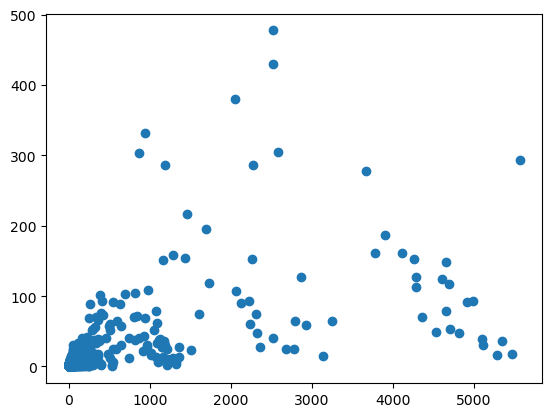

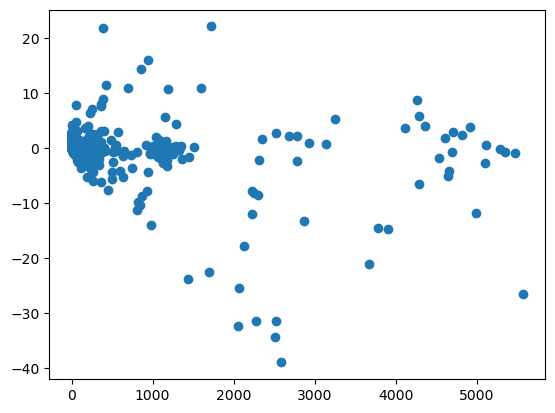

In [23]:
datar=pd.DataFrame(np.vstack(manager_random.data))
print(datar.shape)

plt.scatter(datar[0],datar[1])
plt.figure()
plt.scatter(datar[0],datar[2])
plt.show()

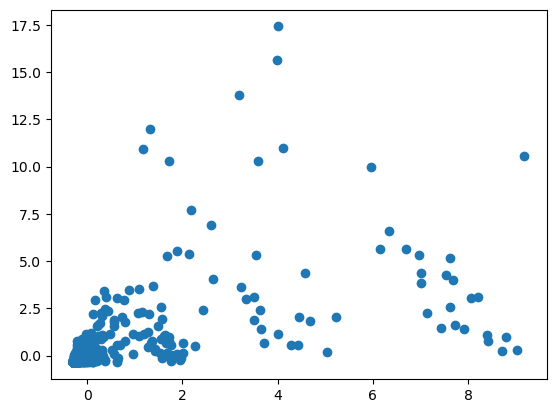

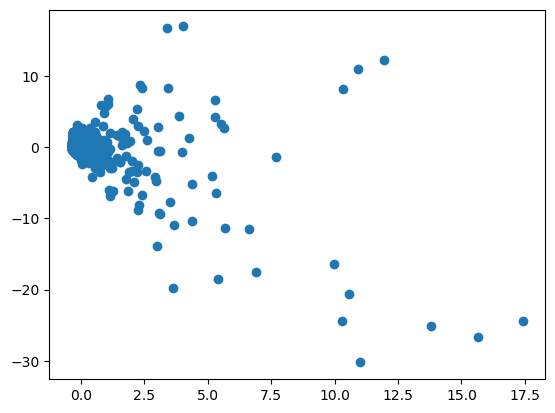

In [24]:
plt.scatter((datar[0]-mean[0])/np.sqrt(renorm[0,0]),(datar[1]-mean[1])/np.sqrt(renorm[1,1]))
plt.figure()
plt.scatter((datar[1]-mean[1])/np.sqrt(renorm[1,1]),(datar[2]-mean[2])/np.sqrt(renorm[2,2]))

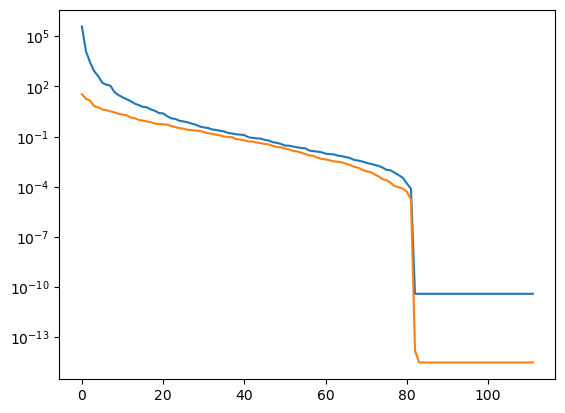

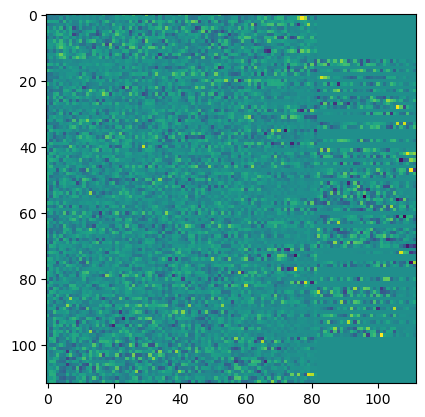

In [25]:
plt.semilogy(manager_random.s)

u,s,vh=np.linalg.svd(np.divide(covariance,renorm))

plt.semilogy(s)

plt.figure()
plt.imshow(u)

In [26]:
renorm

array([[3.45471638e+05, 1.57929425e+04, 7.61067694e+02, ...,
        1.31703800e+04, 9.74128872e+02, 2.56003343e+03],
       [1.57929425e+04, 7.21960955e+02, 3.47915633e+01, ...,
        6.02072735e+02, 4.45314741e+01, 1.17029754e+02],
       [7.61067694e+02, 3.47915633e+01, 1.67661820e+00, ...,
        2.90141059e+01, 2.14598807e+00, 5.63970678e+00],
       ...,
       [1.31703800e+04, 6.02072735e+02, 2.90141059e+01, ...,
        5.02093050e+02, 3.71366155e+01, 9.75958929e+01],
       [9.74128872e+02, 4.45314741e+01, 2.14598807e+00, ...,
        3.71366155e+01, 2.74675821e+00, 7.21854475e+00],
       [2.56003343e+03, 1.17029754e+02, 5.63970678e+00, ...,
        9.75958929e+01, 7.21854475e+00, 1.89705042e+01]])

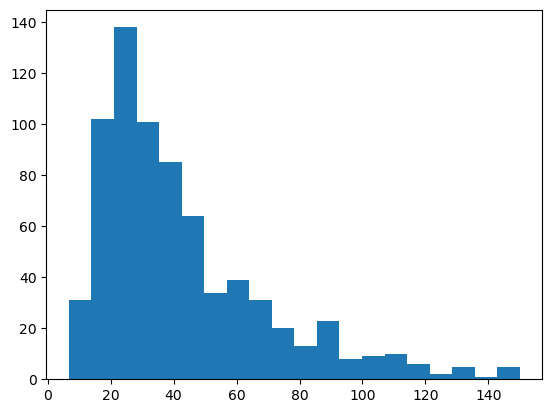

In [27]:
plt.hist(target_V, bins=20)
plt.show()

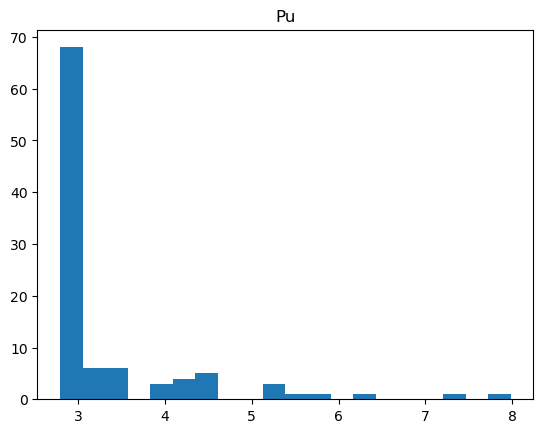

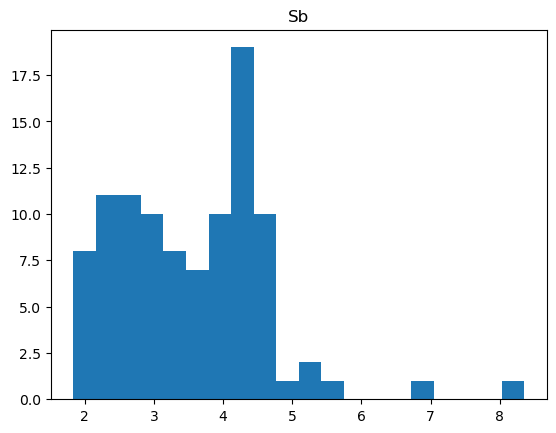

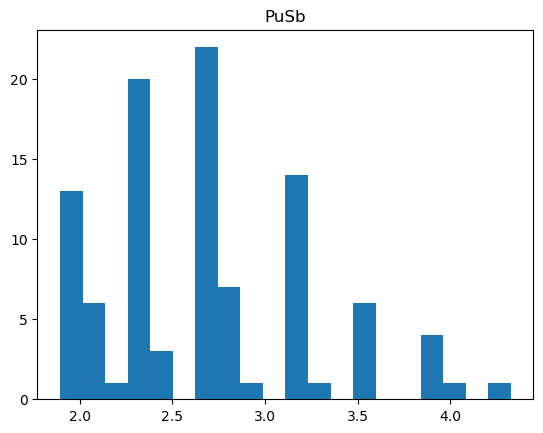

In [28]:
target_D = np.asarray(target_D)
plt.hist(target_D[:,0], bins=20)
plt.title("Pu")
plt.show()

plt.hist(target_D[:,1], bins=20)
plt.title("Sb")
plt.show()

plt.hist(target_D[:,2], bins=20)
plt.title("PuSb")
plt.show()